<a href="https://colab.research.google.com/github/Kunj-7007/AI_ML_Workshop_LDRP/blob/main/Tranfser_learning__assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving OneDrive_2026-04-02.zip to OneDrive_2026-04-02.zip


In [ ]:
import zipfile


zip_path = "/content/OneDrive_2026-04-02.zip"   # your uploaded file

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done!")

data_dir = "/content/dataset/satellite_dataset"

Extraction Done!


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [ ]:
#Load dataset
img_size = (96, 96)
batch_size = 64

data_dir = "/content/dataset/Satellite Image data"

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 5631 files belonging to 4 classes.
Using 4505 files for training.
Found 5631 files belonging to 4 classes.
Using 1126 files for validation.


In [ ]:
# Class names
print(class_names)

['cloudy', 'desert', 'green_area', 'water']


In [ ]:
#Normalization
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
test_data = test_data.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
for images, labels in train_data.take(1):
    print(labels.shape)

(64,)


In [ ]:
#Load Transfer Learning Model
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False

In [ ]:
#Build Model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

In [ ]:
#Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
#Train Model
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 44s 389ms/step - accuracy: 0.9134 - loss: 0.2993 - val_accuracy: 0.9831 - val_loss: 0.0802
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9860 - loss: 0.0584 - val_accuracy: 0.9778 - val_loss: 0.0649
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9885 - loss: 0.0408 - val_accuracy: 0.9858 - val_loss: 0.0443
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9893 - loss: 0.0365 - val_accuracy: 0.9876 - val_loss: 0.0379
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9900 - loss: 0.0355 - val_accuracy: 0.9858 - val_loss: 0.0351
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9925 - loss: 0.0280 - val_accuracy: 0.9858 - val_loss: 0.0364
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9945 - loss: 0.0227 - val_accuracy: 0.9911 - val_loss: 0.0303
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9929 - loss: 0.0227 - val_accuracy: 0.9876 -

In [ ]:
#Predictions
y_true = []
y_pred = []

for images, labels in test_data:
    probs = model.predict(images)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


In [ ]:
#Accuracy + Report
print("\nSklearn Accuracy :", accuracy_score(y_true, y_pred))

print("\nClassification Report :")
print(classification_report(y_true, y_pred, target_names=class_names))


Sklearn Accuracy : 0.9902309058614565

Classification Report :
              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00       267
      desert       1.00      1.00      1.00       224
  green_area       0.99      0.98      0.98       318
       water       0.98      0.98      0.98       317

    accuracy                           0.99      1126
   macro avg       0.99      0.99      0.99      1126
weighted avg       0.99      0.99      0.99      1126



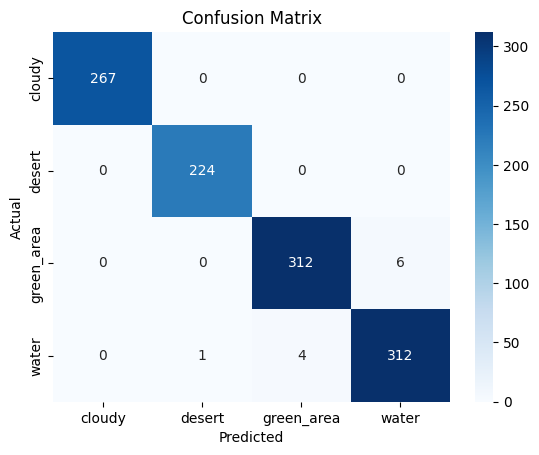

In [ ]:
#Confusion Matrix
import seaborn as sns

conf_matrix = confusion_matrix(y_true, y_pred)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()